<a href="https://colab.research.google.com/github/andrealopez47/goatdevice_evaluation/blob/main/Gps_laboratorio_Graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

===== 2D ERROR METRICS =====

Mean Horizontal Error: 6.8802 m
RMS Horizontal Error: 7.3151 m
Bias Vector μ = [0.0407, 4.6679] m
Bias Magnitude P_F = 4.6681 m

Covariance Matrix K_e =
[[20.65516482 -5.33031054]
 [-5.33031054 12.05550267]]

Trace(K_e) = 32.7107 m²

CEP50 = 7.7836 m
CEP95 = 9.7684 m
σ_|e_h| = 2.5233 m

===== METRICS TABLE =====

 mu_x (m)  mu_y (m)  P_F (m)  K_e_11 (m²)  K_e_12 (m²)  K_e_21 (m²)  K_e_22 (m²)  Trace(K_e) (m²)  Mean Error (m)  RMS Error (m)  CEP50 (m)  CEP95 (m)  Sigma |e_h| (m)
 0.040748  4.667941 4.668118    20.655165    -5.330311    -5.330311    12.055503        32.710667         6.88017       7.315105   7.783634   9.768419         2.523286


/tmp/ipykernel_8151/996883858.py:299: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


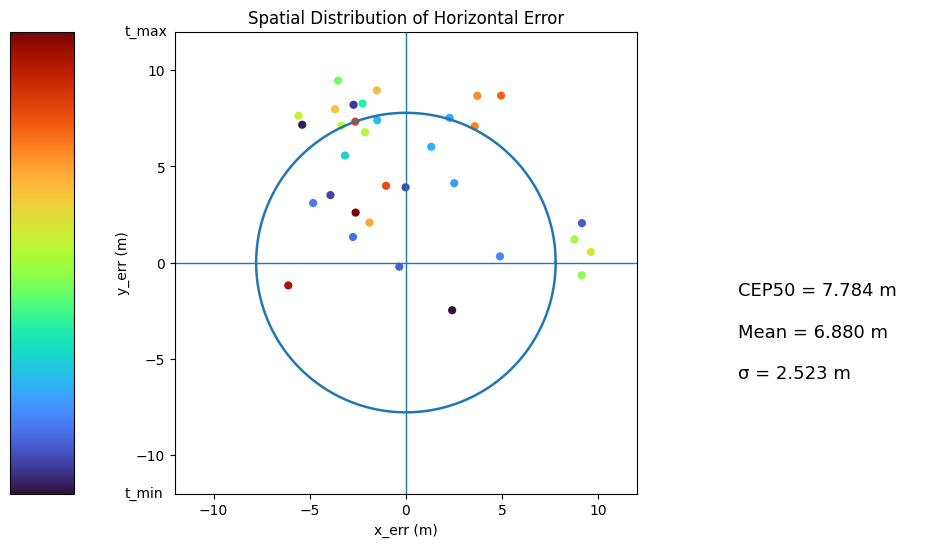

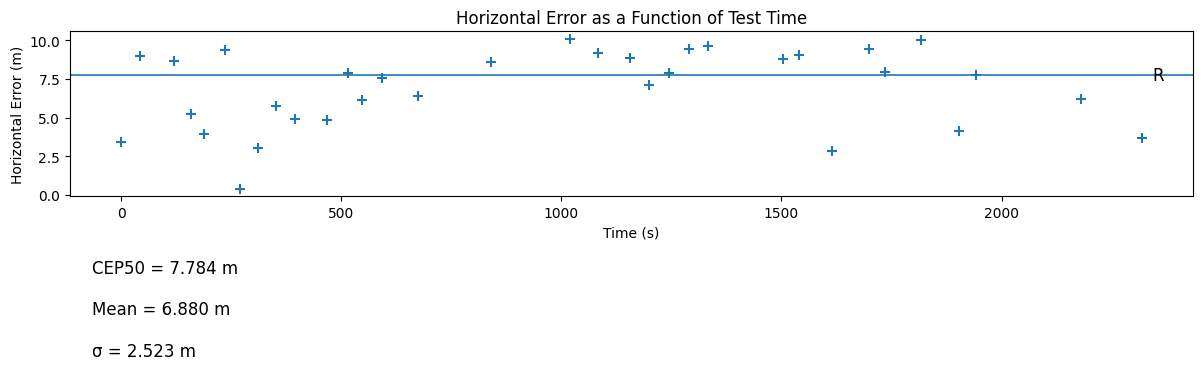

In [ ]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime


# ==========================================
# LOAD CSV FILE
# ==========================================

file_path = "/content/sample_data/gps_laboratorio.csv"

df = pd.read_csv(file_path)


# ==========================================
# CONVERT LAT/LON TO LOCAL ERRORS
# ==========================================

R_earth = 6371000.0

lat_ref = np.deg2rad(df["Lat EC"].values)

lon_ref = np.deg2rad(df["Lon EC"].values)

lat_test = np.deg2rad(df["Lat EBP"].values)

lon_test = np.deg2rad(df["Lon EBP"].values)

lat_mean = (lat_ref + lat_test) / 2.0

# Local horizontal error components
x_err = (
    (lon_test - lon_ref)
    * np.cos(lat_mean)
    * R_earth
)

y_err = (
    (lat_test - lat_ref)
    * R_earth
)

# Horizontal error magnitude
eh = np.sqrt(
    x_err**2 +
    y_err**2
)


# ==========================================
# TIME CONVERSION
# ==========================================

def time_to_seconds(t):

    dt = datetime.strptime(t, "%H:%M:%S")

    return (
        dt.hour * 3600 +
        dt.minute * 60 +
        dt.second
    )


t_sec = np.array([
    time_to_seconds(t)
    for t in df["Hora EC"]
])

# Relative time
t_rel = t_sec - t_sec[0]


# ==========================================
# METRICS
# ==========================================

CEP50 = np.percentile(eh, 50)

CEP95 = np.percentile(eh, 95)

mean_eh = np.mean(eh)

sigma_eh = np.std(eh, ddof=1)

rms_eh = np.sqrt(np.mean(eh**2))


# ==========================================
# BIAS VECTOR
# ==========================================

mu_x = np.mean(x_err)

mu_y = np.mean(y_err)

P_F = np.sqrt(
    mu_x**2 +
    mu_y**2
)


# ==========================================
# COVARIANCE MATRIX
# ==========================================

E = np.vstack([x_err, y_err])

K_e = np.cov(E, bias=False)

tr_Ke = np.trace(K_e)


# ==========================================
# PRINT RESULTS
# ==========================================

print("===== 2D ERROR METRICS =====\n")

print(f"Mean Horizontal Error: {mean_eh:.4f} m")

print(f"RMS Horizontal Error: {rms_eh:.4f} m")

print(f"Bias Vector μ = [{mu_x:.4f}, {mu_y:.4f}] m")

print(f"Bias Magnitude P_F = {P_F:.4f} m")

print("\nCovariance Matrix K_e =")

print(K_e)

print(f"\nTrace(K_e) = {tr_Ke:.4f} m²")

print(f"\nCEP50 = {CEP50:.4f} m")

print(f"CEP95 = {CEP95:.4f} m")

print(f"σ_|e_h| = {sigma_eh:.4f} m")


# ==========================================
# METRICS TABLE
# ==========================================

metrics_2d = pd.DataFrame({

    "mu_x (m)": [mu_x],

    "mu_y (m)": [mu_y],

    "P_F (m)": [P_F],

    "K_e_11 (m²)": [K_e[0, 0]],

    "K_e_12 (m²)": [K_e[0, 1]],

    "K_e_21 (m²)": [K_e[1, 0]],

    "K_e_22 (m²)": [K_e[1, 1]],

    "Trace(K_e) (m²)": [tr_Ke],

    "Mean Error (m)": [mean_eh],

    "RMS Error (m)": [rms_eh],

    "CEP50 (m)": [CEP50],

    "CEP95 (m)": [CEP95],

    "Sigma |e_h| (m)": [sigma_eh]
})

print("\n===== METRICS TABLE =====\n")

print(metrics_2d.to_string(index=False))


# ==========================================
# FIGURE 1
# SPATIAL ERROR DISTRIBUTION
# ==========================================

fig = plt.figure(figsize=(12, 6))

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[0.12, 1.0, 0.38],
    wspace=0.25
)

# Axes
cax = fig.add_subplot(gs[0, 0])

ax = fig.add_subplot(gs[0, 1])

tax = fig.add_subplot(gs[0, 2])


# Scatter plot
sc = ax.scatter(
    x_err,
    y_err,
    c=t_rel,
    cmap="turbo",
    s=35,
    edgecolors="none"
)


# CEP50 circle
theta = np.linspace(0, 2*np.pi, 400)

ax.plot(
    CEP50 * np.cos(theta),
    CEP50 * np.sin(theta),
    linewidth=1.8
)


# Central axes
ax.axhline(0, linewidth=1)

ax.axvline(0, linewidth=1)


# Axis limits
max_lim = max(
    np.max(np.abs(x_err)),
    np.max(np.abs(y_err)),
    CEP50
) * 1.25

ax.set_xlim(-max_lim, max_lim)

ax.set_ylim(-max_lim, max_lim)

ax.set_aspect("equal", adjustable="box")


# Labels
ax.set_xlabel("x_err (m)")

ax.set_ylabel("y_err (m)")

ax.set_title("Spatial Distribution of Horizontal Error")


# Colorbar
cbar = fig.colorbar(sc, cax=cax)

cbar.set_ticks([])

cax.text(
    1.8,
    1.00,
    "t_max",
    transform=cax.transAxes,
    ha="left",
    va="center",
    fontsize=10
)

cax.text(
    1.8,
    0.00,
    "t_min",
    transform=cax.transAxes,
    ha="left",
    va="center",
    fontsize=10
)


# Metrics text
tax.axis("off")

textstr = (
    f"CEP50 = {CEP50:.3f} m\n\n"
    f"Mean = {mean_eh:.3f} m\n\n"
    f"σ = {sigma_eh:.3f} m"
)

tax.text(
    0.0,
    0.35,
    textstr,
    fontsize=13,
    va="center",
    ha="left"
)

plt.tight_layout()

plt.show()


# ==========================================
# FIGURE 2
# ERROR VS TIME
# ==========================================

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.scatter(
    t_rel,
    eh,
    marker="+",
    s=50
)


# CEP50 reference line
ax.axhline(
    CEP50,
    linewidth=1.2
)

ax.text(
    t_rel.max() * 1.01,
    CEP50,
    "R",
    va="center",
    ha="left",
    fontsize=12
)


# Labels
ax.set_xlabel("Time (s)")

ax.set_ylabel("Horizontal Error (m)")

ax.set_title("Horizontal Error as a Function of Test Time")


# Metrics text block
texto = (
    f"CEP50 = {CEP50:.3f} m\n\n"
    f"Mean = {mean_eh:.3f} m\n\n"
    f"σ = {sigma_eh:.3f} m"
)

ax.text(
    0.02,
    -0.38,
    texto,
    transform=ax.transAxes,
    fontsize=12,
    va="top"
)

plt.tight_layout()

plt.show()